In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
img = cv2.imread('IMG_bima_eldi.jpg')
img = cv2.resize(img, (1080, 1080))
frame = img.copy()

In [ ]:
age_weights = "/content/age_deploy.prototxt"
age_config = "/content/age_net.caffemodel"
age_Net = cv2.dnn.readNet(age_weights, age_config)

In [ ]:
ageList = ['(0-2)', '(4-6)', '(8-12)', '(15-20)',
           '(25-32)', '(38-43)', '(48-53)', '(60-100)']
model_mean = (78.4263377603, 87.7689143744, 114.895847746)

In [ ]:
fH= img.shape[0]
fW= img.shape[1]

Boxes = []
mssg = 'usia'

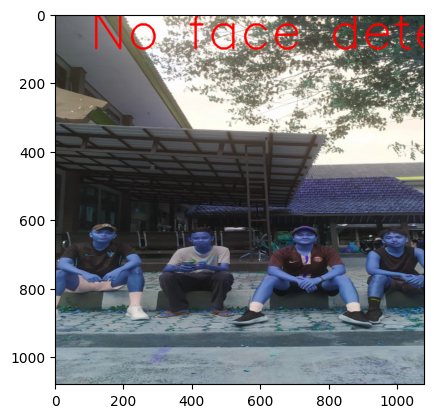

In [ ]:
face_detector = dlib.get_frontal_face_detector()
img_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
faces = face_detector(img_gray)
if not faces:
  mssg = 'No face detected'
  cv2.putText(img, f'{mssg}', (100, 100),
              cv2.FONT_HERSHEY_SIMPLEX, 5, (300), 5)
  plt.imshow(img)
  cv2.waitKey(0)
else:
  for face in faces:
    x = face.left()
    y = face.top()
    x2 = face.right()
    y2 = face.bottom()

    box = [x, y, x2, y2]
    Boxes.append(box)
    cv2.rectangle(frame, (x, y), (x2, y2),
                      (00, 400, 400), 2)

  for box in Boxes:
    face = frame[box[1]:box[3], box[0]:box[2]]
    blob = cv2.dnn.blobFromImage(
        face, 1.0, (255, 255), model_mean, swapRB=False)
    age_Net.setInput(blob)
    age_preds = age_Net.forward()
    age = ageList[age_preds[0].argmax()]

    cv2.putText(frame, f'{mssg}:{age}', (box[0],
                                         box[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2,
                (255,255,255), 4, cv2.LINE_AA)
    plt.imshow(frame)

In [ ]:
data_rgb = cv2.cvtColor(frame, cv2.COLOR_XYZ2BGR)
cv2.imwrite('wa13.jpg', data_rgb)

True